In [1]:
# input
anno_domain_cath = "./tmp/anno_repId-cath.tsv"
pred_domain_cath = "./tmp/pred_repId-cath.tsv"
# output
fig_file = "./fig/labelled_cath_pca.pdf"
inter_file = "./fig/anno_pred_cath.pdf"
cat_comp_file = "./fig/cat_composition.pdf"

In [2]:
import pandas as pd
anno_labels = set(pd.read_table(anno_domain_cath, header=None)[1])
pred_labels = set(pd.read_table(pred_domain_cath, header=None)[1])
all_labels = anno_labels | pred_labels
len(anno_labels)
len(pred_labels)
len(all_labels)
len(anno_labels & pred_labels)

1994

4513

4644

1863

In [3]:
# only cat
anno_labels = set([i if i.count(".") == 2 else ".".join(i.split(".")[:3]) for i in anno_labels])
pred_labels = set([i if i.count(".") == 2 else ".".join(i.split(".")[:3]) for i in pred_labels])
all_labels = anno_labels | pred_labels
len(anno_labels)
len(pred_labels)
len(anno_labels & pred_labels)

698

1178

688

In [4]:
from matplotlib_venn import venn2

<Figure size 240x240 with 0 Axes>

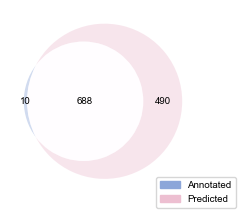

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
colors = ["#8CA6D9", "#EDBFD1"]

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
plt.figure(figsize=(2.4, 2.4))

venn2([anno_labels, pred_labels], set_colors=colors, set_labels=None)
legend_patches = [
    Patch(color=colors[0], label="Annotated"),
    Patch(color=colors[1], label="Predicted")
]

plt.legend(handles=legend_patches, loc="center", bbox_to_anchor=(1, 0))
plt.savefig(inter_file, bbox_inches='tight', transparent=True)

In [6]:
records = []
for d in all_labels:
    cath_labels = d.split(".")
    if len(cath_labels) == 4:
        pass
    elif len(cath_labels) == 3:
        cath_labels.append("-1")
    else:
        raise ValueError()
    
    cath_labels = [int(i) for i in cath_labels]
    records.append({
        "cath": cath_labels,
        "has_anno": d in anno_labels,
        "class": cath_labels[0]
    })
df = pd.DataFrame(records)

In [7]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
encoded_features = encoder.fit_transform(np.stack(df['cath'])).toarray()

# === PCA 降维 ===
pca = PCA(n_components=2)  # 2D PCA
pca_result = pca.fit_transform(encoded_features)

<Figure size 300x300 with 0 Axes>

([<matplotlib.axis.YTick at 0x7eed09c3ad90>,
 [Text(0, -0.5, '−0.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5')])

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

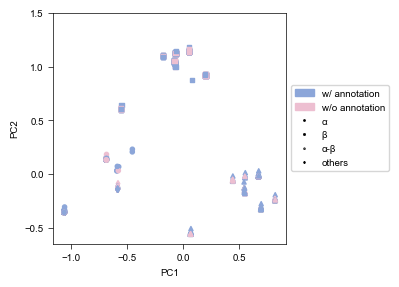

In [8]:
import matplotlib.pyplot as plt
plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

# === 2D 可视化 ===
marker_dict = {1: "o", 2: "s", 3: "^", 4: "d"}
color_dict = {True: "#8CA6D9", False: "#EDBFD1"}
plt.figure(figsize=(3, 3))
for c_val in sorted(df["class"].unique()):
    idx = df["class"] == c_val
    has_anno = df[idx]['has_anno']
    plt.scatter(
        pca_result[idx, 0], 
        pca_result[idx, 1], 
        marker=marker_dict[c_val], 
        s=9,
        c=[color_dict[i] for i in has_anno],
    )

plt.yticks([-0.5, 0, 0.5, 1, 1.5])
plt.xlabel("PC1")
plt.ylabel("PC2")

import matplotlib.patches as mpatches
import matplotlib.lines as mlines
# 1. 颜色说明 Legend
color_legend = [
    mpatches.Patch(color=color_dict[True], label="w/ annotation"),
    mpatches.Patch(color=color_dict[False], label="w/o annotation")
]

# 2. 形状说明 Legend
shape_legend = [
    mlines.Line2D([], [], marker=marker_dict[1], linestyle="None", markersize=1, markerfacecolor="none", markeredgecolor="black", label="α"),
    mlines.Line2D([], [], marker=marker_dict[2], linestyle="None", markersize=1, markerfacecolor="none", markeredgecolor="black", label="β"),
    mlines.Line2D([], [], marker=marker_dict[3], linestyle="None", markersize=1, markerfacecolor="none", markeredgecolor="black", label="α-β"),
    mlines.Line2D([], [], marker=marker_dict[4], linestyle="None", markersize=1, markerfacecolor="none", markeredgecolor="black", label="others")
]

# 创建单个 legend
plt.legend(handles=color_legend + shape_legend, loc="center left", bbox_to_anchor=(1, 0.5))
plt.savefig(fig_file, bbox_inches="tight", transparent=True)

In [13]:
from typing import Counter

c_to_label = {
    "1": "mainly alpha",
    "2": "mainly beta",
    "3": "alpha-beta",
    "4": "few secondary structure"
}

uniq_pred_cats = list(pred_labels - (pred_labels & anno_labels))
uniq_pred_c = [c_to_label[i[0]] for i in uniq_pred_cats]
data = Counter(uniq_pred_c)
data

Counter({'alpha-beta': 216,
         'mainly alpha': 151,
         'mainly beta': 94,
         'few secondary structure': 29})

<Figure size 300x300 with 0 Axes>

([<matplotlib.patches.Wedge at 0x7ab82a0c3e10>,
 [Text(0.623531134334021, 0.9062057848613245, ''),
  Text(-1.0823225159268028, -0.1964127580323532, ''),
  Text(0.6177083313655161, -0.9101848259346175, ''),
  Text(1.0810409242434333, -0.2033482729479251, '')],
 [Text(0.3401078914549205, 0.49429406446981333, '30.8%'),
  Text(-0.5903577359600742, -0.10713423165401083, '44.1%'),
  Text(0.33693181710846326, -0.49646445050979127, '19.2%'),
  Text(0.5896586859509635, -0.11091723978977731, '5.9%')])

Text(0.5, 1.0, 'Total 490 CAT labels')

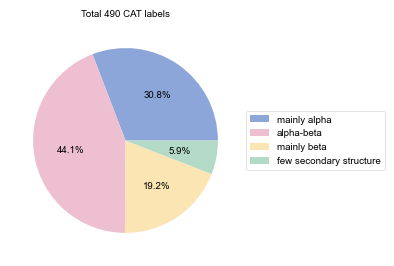

In [17]:
import matplotlib.pyplot as plt

x = ['mainly alpha', 'alpha-beta', 'mainly beta', 'few secondary structure']
y = [data[i] for i in x]

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

plt.figure(figsize=(3, 3))
plt.pie(y, autopct="%.1f%%")
plt.legend(
    labels=x,
    loc='center left',
    bbox_to_anchor=(1,.5)
)
plt.title("Total 490 CAT labels")
plt.savefig(cat_comp_file, bbox_inches="tight", transparent=True)